
C_R1s(r) =
+17.4697 * exp(-8.4936 r)
+10.2078 * exp(-4.8788 r)
-7.3550 * r^2 * exp(-15.4660 r)
+32.1360 * r * exp(-7.0500 r)
+0.0079 * r * exp(-2.2640 r)
+0.0014 * r * exp(-1.4747 r)
-0.0002 * r * exp(-1.1639 r)

C_R2s(r) =
-3.5510 * exp(-8.4936 r)
+9.4467 * exp(-4.8788 r)
-2.3494 * r^2 * exp(-15.4660 r)
-13.8966 * r * exp(-7.0500 r)
-3.5008 * r * exp(-2.2640 r)
-1.7660 * r * exp(-1.4747 r)
-0.2127 * r * exp(-1.1639 r)

C_R2p(r) =
+1.0632 * r * exp(-7.0500 r)
+1.5316 * r * exp(-3.2275 r)
+1.8933 * r * exp(-2.1908 r)
+1.1863 * r * exp(-1.4413 r)
+0.4299 * r * exp(-1.0242 r)


/tmp/ipykernel_7530/2787428155.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 1.0000002173562614
Norm 2s = 0.999998505923573
Norm 2p = 0.9999997486127472
           Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0       0.00       1.532002e-01       8.047656e-01       4.797157e-01   
1       0.05       1.531611e-01       7.995971e-01       4.796919e-01   
2       0.10       1.530438e-01       7.843303e-01       4.794846e-01   
3       0.15       1.528487e-01       7.596591e-01       4.787147e-01   
4       0.20       1.525761e-01       7.266708e-01       4.768415e-01   
...      ...                ...                ...                ...   
1996   99.80       5.850373e-09       2.656543e-10       8.980358e-14   
1997   99.85       5.832883e-09       2.648590e-10       8.944548e-14   
1998   99.90       5.815454e-09       2.640664e-10       8.908899e-14   
1999   99.95       5.798085e-09       2.632766e-10       8.873409e-14   
2000  100.00       5.780777e-09       2.624896e-10       8.838078e-14   

         J_total_C  
0     2.875363e+

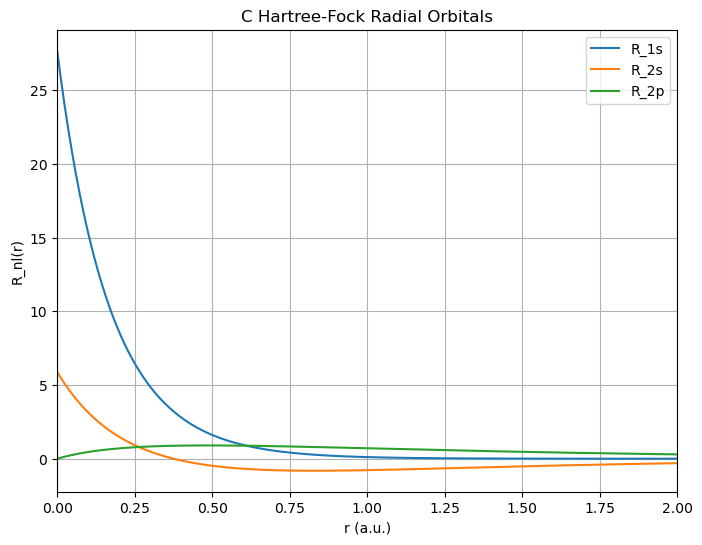

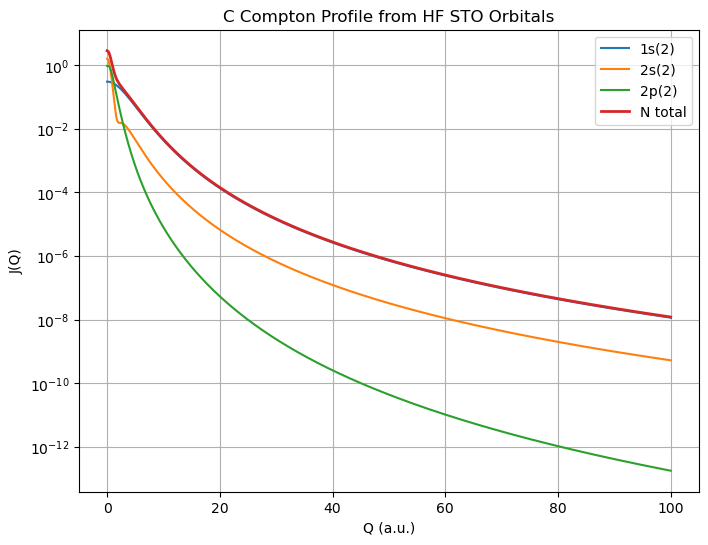

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Carbon Hartree-Fock STO data
# C: 1s2 2s2 2p2
# Ground term: 2p
# Format: (n_j, Z_j, C_j)
# =====================================================

carbon_1s = [
    (1, 8.4936,  0.352872),
    (1, 4.8788,  0.473621),
    (3,15.4660, -0.001199),
    (2, 7.0500,  0.210887),
    (2, 2.2640,  0.000886),
    (2, 1.4747,  0.000465),
    (2, 1.1639, -0.000119),
]

carbon_2s = [
    (1, 8.4936, -0.071727),
    (1, 4.8788,  0.438307),
    (3,15.4660, -0.000383),
    (2, 7.0500, -0.091194),
    (2, 2.2640, -0.393105),
    (2, 1.4747, -0.579121),
    (2, 1.1639, -0.126067),
]

carbon_2p = [
    (2, 7.0500, 0.006977),
    (2, 3.2275, 0.070877),
    (2, 2.1908, 0.230802),
    (2, 1.4413, 0.411931),
    (2, 1.0242, 0.350701),
]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, carbon_1s)
R2s = R_nl(r, carbon_2s)
R2p = R_nl(r, carbon_2p)

print_R_formula(carbon_1s, "C_R1s")
print_R_formula(carbon_2s, "C_R2s")

print_R_formula(carbon_2p, "C_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))

# C: 1s2 2s2 2p2
J_total = 2*J_1s + 2*J_2s + 2*J_2p   

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_total_C": J_total
    })
print(table)
table.to_csv("C_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("C Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 2*J_2p, label="2p(2)")
plt.plot(Q, J_total, label="N total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("C Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()